### Overall Business Performance
### This section provides a high level overview of the company's performance by analyzing key business metrics

In [123]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

In [124]:
df = pd.read_csv("/Users/aryaapalande/Desktop/Superstore_sales_project/superstore_data_cleaned/final_superstore_dataset.csv")


In [125]:
#Convert the date columns again
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

In [126]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 27 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Row ID            10194 non-null  int64         
 1   Order ID          10194 non-null  object        
 2   Order Date        10194 non-null  datetime64[ns]
 3   Ship Date         10194 non-null  datetime64[ns]
 4   Ship Mode         10194 non-null  object        
 5   Customer ID       10194 non-null  object        
 6   Customer Name     10194 non-null  object        
 7   Segment           10194 non-null  object        
 8   Country/Region    10194 non-null  object        
 9   City              10194 non-null  object        
 10  State/Province    10194 non-null  object        
 11  Postal Code       10194 non-null  object        
 12  Region            10194 non-null  object        
 13  Product ID        10194 non-null  object        
 14  Category          1019

In [127]:
#Total sales
total_sales = df['Sales'].sum()
print(f"Total Sales: ${total_sales:,.2f}")

Total Sales: $2,326,534.35


In [128]:
#Total profit
total_profit = df['Profit'].sum()
print(f"Total Profit: ${total_profit:,.2f}")

Total Profit: $292,296.81


In [129]:
#Total orders
total_orders = df['Order ID'].nunique()
print(f"Total Orders: {total_orders}")

Total Orders: 5111


In [130]:
#Average order value
aov = df.groupby('Order ID')['Sales'].sum().mean()
print(f"Average Order Value: ${aov:,.2f}")

Average Order Value: $455.20


In [131]:
#KPI summary table
kpi = pd.DataFrame({
    "Metric": [
        "Total Sales",
        "Total Profit",
        "Total Orders",
        "Average Order Value"
    ],
    "Value": [
        total_sales,
        total_profit,
        total_orders,
        aov
    ]
})
kpi

,Metric,Value
0,Total Sales,2.326534e+06
1,Total Profit,2.922968e+05
2,Total Orders,5.111000e+03
3,Average Order Value,4.552014e+02


### Category Analysis
Answers question 'Which product category generates the highest sales and profit?'
Analyze sales and profit across different product categories to identify the best performing category.

In [132]:
#Sales by Category
sales_by_category = (
    df.groupby('Category')['Sales']
      .sum()
      .sort_values(ascending=False)
)
sales_by_category

Category
Technology         839893.2790
Furniture          754747.7613
Office Supplies    731893.3140
Name: Sales, dtype: float64

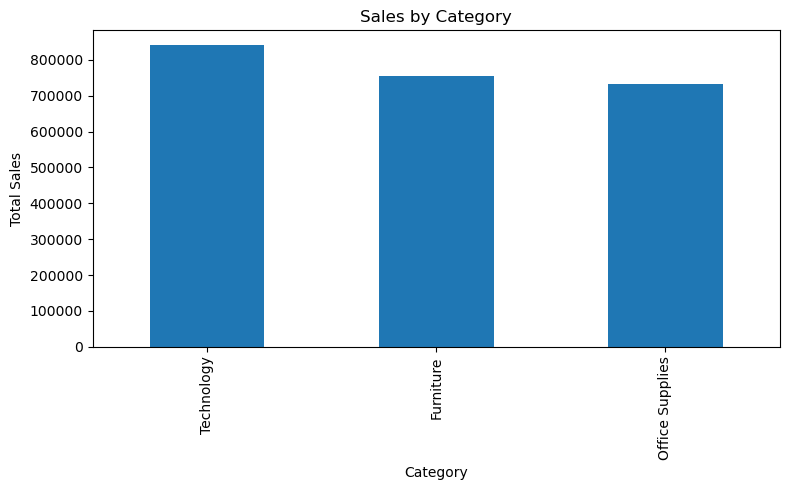

In [133]:
#Sales by Category visualization
plt.figure(figsize=(8,5))
sales_by_category.plot(kind='bar')
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.show()

In [134]:
#Profit by Category
profit_by_category = (
    df.groupby('Category')['Profit']
      .sum()
      .sort_values(ascending=False)
)
profit_by_category

Category
Technology         146543.3756
Office Supplies    126023.4434
Furniture           19729.9956
Name: Profit, dtype: float64

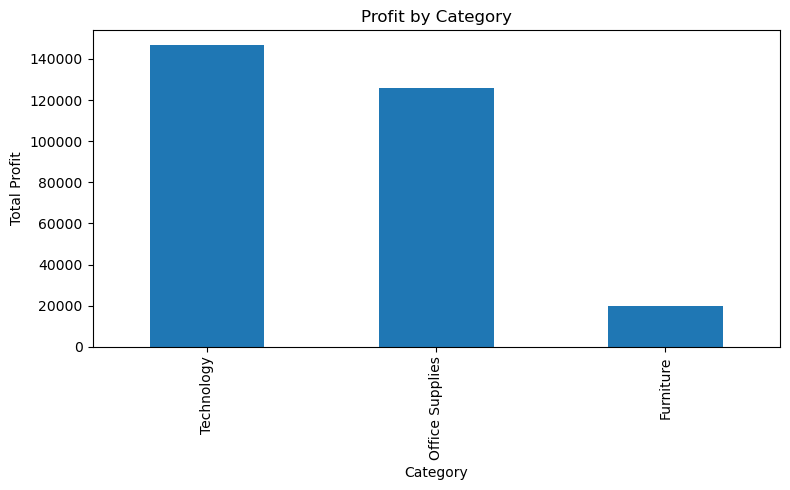

In [135]:
#Profit by Category visualization
plt.figure(figsize=(8,5))
profit_by_category.plot(kind='bar')
plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Total Profit")
plt.tight_layout()
plt.show()

### Observation
- Technology generated the highest sales.
- Office Supplies had moderate sales but strong profitability.
- Furniture generated good sales but comparatively lower profit.
### Business Insight
Technology is the strongest performing category in terms of both sales and profit indicating high customer demand and healthy margins. Furniture contributes significantly to sales but may require pricing or cost optimization to improve profitability.

### Sub Category Analysis
Answers question 'Which sub-categories contribute the most to sales and profit and which ones are making losses?'
Analyze sales and profit at the sub category level to identify high performing and underperforming products.

In [136]:
#Sales by Sub-Category
sales_by_subcategory = (
    df.groupby('Sub-Category')['Sales']
      .sum()
      .sort_values(ascending=False)
)
sales_by_subcategory

Sub-Category
Chairs         335768.2490
Phones         331842.6400
Storage        224644.5540
Tables         208020.1820
Binders        207354.8810
Machines       189925.0310
Accessories    167380.3180
Copiers        150745.2900
Bookcases      115361.2043
Appliances     108213.1850
Furnishings     95598.1260
Paper           79540.5380
Supplies        46725.4980
Art             27659.0140
Envelopes       16528.3620
Labels          12695.0420
Fasteners        8532.2400
Name: Sales, dtype: float64

In [137]:
#Profit by Sub-Category
profit_by_subcategory = (
    df.groupby('Sub-Category')['Profit']
      .sum()
      .sort_values(ascending=False)
)
profit_by_subcategory

Sub-Category
Copiers        56093.9365
Phones         45050.8265
Accessories    41936.6357
Paper          34511.5070
Binders        31426.1003
Chairs         27223.5323
Storage        21285.1115
Appliances     18329.4844
Furnishings    13891.7430
Envelopes       6988.0247
Art             6653.1962
Labels          5572.7780
Machines        3461.9769
Fasteners       2428.6358
Supplies       -1171.3945
Bookcases      -3632.0736
Tables        -17753.2061
Name: Profit, dtype: float64

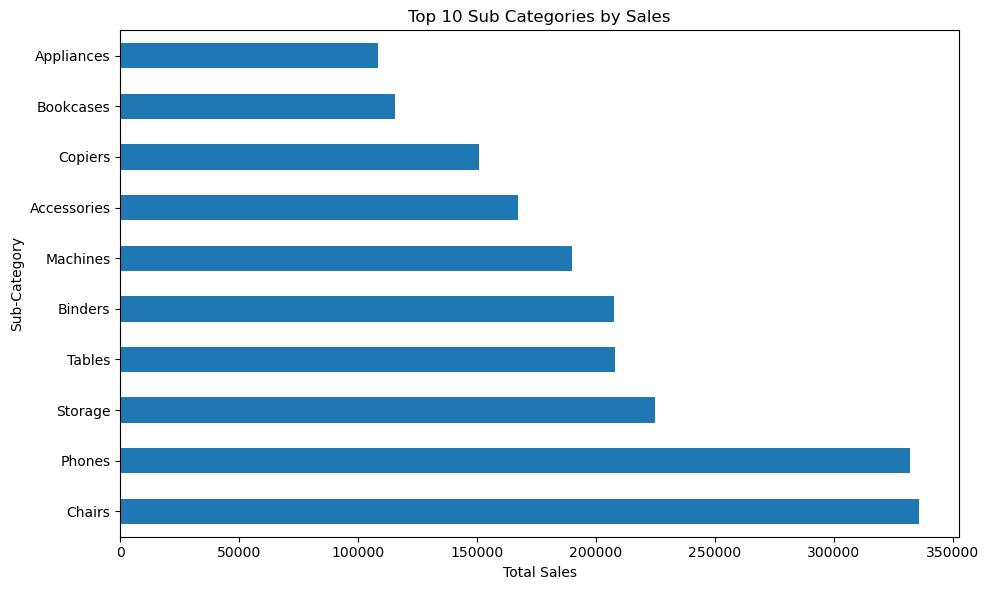

In [138]:
#Top 10 Sub-Categories by Sales
top_sales = sales_by_subcategory.head(10)
plt.figure(figsize=(10,6))
top_sales.plot(kind='barh')
plt.title("Top 10 Sub Categories by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Sub-Category")
plt.tight_layout()
plt.show()

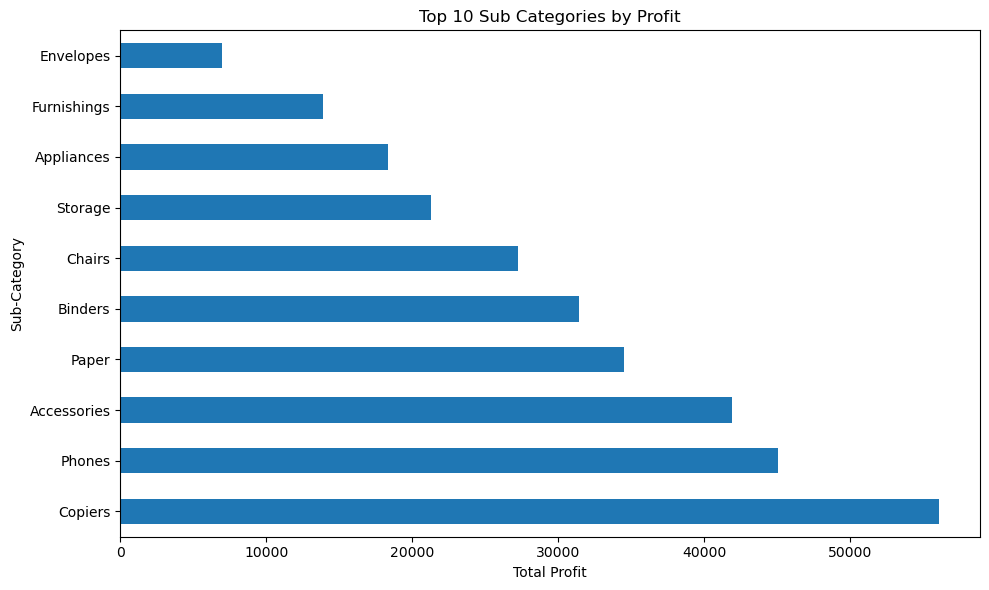

In [139]:
#Top 10 Sub-Categories by Profit
top_profit = profit_by_subcategory.head(10)
plt.figure(figsize=(10,6))
top_profit.plot(kind='barh')
plt.title("Top 10 Sub Categories by Profit")
plt.xlabel("Total Profit")
plt.ylabel("Sub-Category")
plt.tight_layout()
plt.show()

In [140]:
#Loss Making Sub-Categories
loss_subcategories = (
    df.groupby('Sub-Category')['Profit']
      .sum()
      .sort_values()
)
loss_subcategories

Sub-Category
Tables        -17753.2061
Bookcases      -3632.0736
Supplies       -1171.3945
Fasteners       2428.6358
Machines        3461.9769
Labels          5572.7780
Art             6653.1962
Envelopes       6988.0247
Furnishings    13891.7430
Appliances     18329.4844
Storage        21285.1115
Chairs         27223.5323
Binders        31426.1003
Paper          34511.5070
Accessories    41936.6357
Phones         45050.8265
Copiers        56093.9365
Name: Profit, dtype: float64

In [141]:
#display only the loss making ones
loss_subcategories[loss_subcategories < 0]

Sub-Category
Tables      -17753.2061
Bookcases    -3632.0736
Supplies     -1171.3945
Name: Profit, dtype: float64

### Observation
- Phones generated the highest sales among all sub-categories.
- Copiers were among the most profitable products.
- Tables and Bookcases generated losses despite contributing to sales.
### Business Insights
High selling sub categories should continue to receive inventory and marketing support. Loss making sub categories require further investigation into pricing, discounts, procurement costs, or return rates to improve profitability.

### Regional Analysis
This answers question 'Which region contributes the highest sales and profit?'

In [142]:
#Sales by region
sales_by_region = (
    df.groupby('Region')['Sales']
      .sum()
      .sort_values(ascending=False)
)
sales_by_region

Region
West       739813.6085
East       691828.1680
Central    503170.6728
South      391721.9050
Name: Sales, dtype: float64

In [143]:
#Profit by region
profit_by_region = (
    df.groupby('Region')['Profit']
      .sum()
      .sort_values(ascending=False)
)


profit_by_region

Region
West       110798.8170
East        94883.2603
South       46749.4303
Central     39865.3070
Name: Profit, dtype: float64

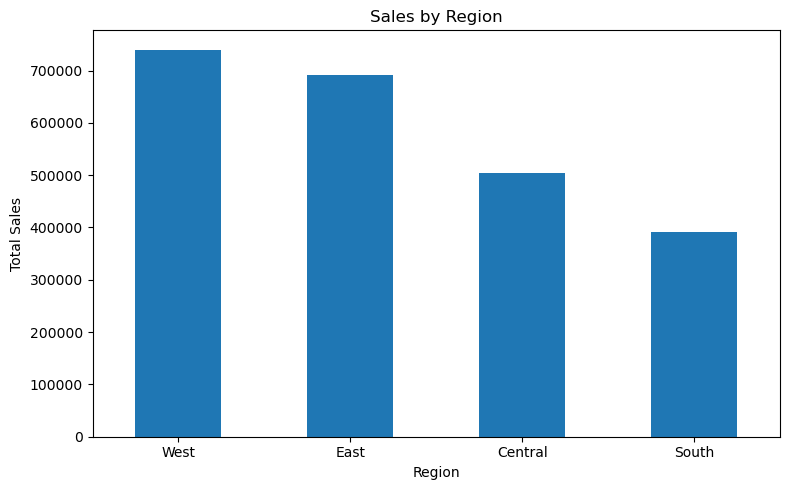

In [144]:
#visualization sales by regoin
plt.figure(figsize=(8,5))
sales_by_region.plot(kind='bar')
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

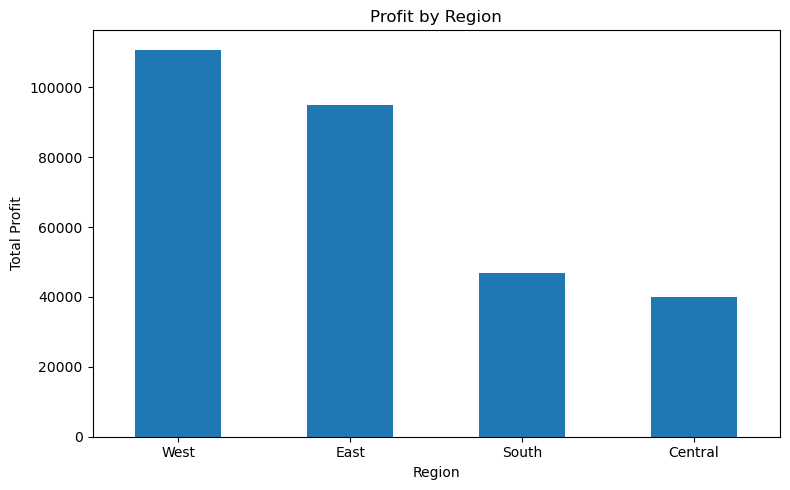

In [145]:
#visualization profit by region
plt.figure(figsize=(8,5))
profit_by_region.plot(kind='bar')
plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Total Profit")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [146]:
#sales by region 
sales_by_region.idxmax(), sales_by_region.max()

('West', 739813.6085)

In [147]:
#highest profit region
profit_by_region.idxmax(), profit_by_region.max()

('West', 110798.817)

In [148]:
#lowest profit region
profit_by_region.idxmin(), profit_by_region.min()

('Central', 39865.307)

In [149]:
#lowest sales region
sales_by_region.idxmin(), sales_by_region.min()

('South', 391721.90499999997)

In [150]:
#highest sales region
sales_by_region.idxmax(), sales_by_region.max()

('West', 739813.6085)

### Observation
- The West region generated the highest sales.
- The West region also earned the highest profit.
- The South region recorded the lowest sales.
- The Central region generated the lowest profit.
### Business Insight
The West region is the strongest-performing region in terms of both sales and profitability. The company should continue investing in this region while investigating the reasons behind the lower performance of the weakest region, such as customer demand, pricing strategy, or operational costs.

### State Analysis
### Business Question
Which states generate the highest sales and profit?
### Objective
Identify the strongest and weakest-performing states to understand geographic sales and profitability patterns.

In [151]:
#Sales by state
sales_by_state = (
    df.groupby('State/Province')['Sales']
      .sum()
      .sort_values(ascending=False)
)
sales_by_state

State/Province
California                   457687.6315
New York                     310876.2710
Texas                        170188.0458
Washington                   138641.2700
Pennsylvania                 116511.9140
Florida                       89473.7080
Illinois                      80166.1010
Ohio                          78258.1360
Michigan                      76269.6140
Virginia                      70636.7200
North Carolina                55603.1640
Indiana                       53555.3600
Georgia                       49095.8400
Kentucky                      36591.7500
New Jersey                    35764.3120
Arizona                       35282.0010
Wisconsin                     32114.6100
Colorado                      32108.1180
Tennessee                     30661.8730
Minnesota                     29863.1500
Massachusetts                 28634.4340
Delaware                      27451.0690
Maryland                      23705.5230
Rhode Island                  22627.9560
M

In [152]:
#top 10 states by sales
top_10_sales_states = sales_by_state.head(10)
top_10_sales_states

State/Province
California      457687.6315
New York        310876.2710
Texas           170188.0458
Washington      138641.2700
Pennsylvania    116511.9140
Florida          89473.7080
Illinois         80166.1010
Ohio             78258.1360
Michigan         76269.6140
Virginia         70636.7200
Name: Sales, dtype: float64

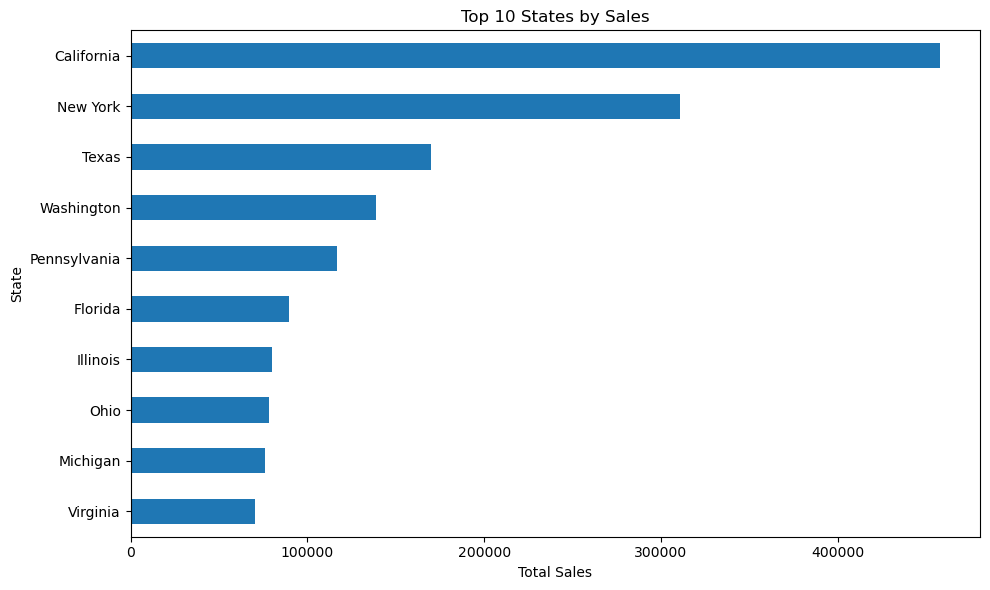

In [153]:
#top 10 states by sales visualization
plt.figure(figsize=(10,6))
top_10_sales_states.sort_values().plot(kind='barh')
plt.title("Top 10 States by Sales")
plt.xlabel("Total Sales")
plt.ylabel("State")
plt.tight_layout()
plt.show()

In [154]:
#profit by sales
profit_by_state = (
    df.groupby('State/Province')['Profit']
      .sum()
      .sort_values(ascending=False)
)
profit_by_state

State/Province
California                   76381.3871
New York                     74038.5486
Washington                   33402.6517
Michigan                     24463.1876
Virginia                     18597.9504
Indiana                      18382.9363
Georgia                      16250.0433
Kentucky                     11199.6966
Minnesota                    10823.1874
Delaware                      9977.3748
New Jersey                    9772.9138
Wisconsin                     8401.8004
Rhode Island                  7285.6293
Maryland                      7031.1788
Massachusetts                 6785.5016
Missouri                      6436.2105
Alabama                       5786.8253
Oklahoma                      4853.9560
Arkansas                      4008.6871
Connecticut                   3511.4918
Nevada                        3316.7659
Mississippi                   3172.9762
Utah                          2546.5335
Vermont                       2244.9783
Alberta                  

In [155]:
#top 10 states by profit
top_10_profit_states = profit_by_state.head(10)
top_10_profit_states

State/Province
California    76381.3871
New York      74038.5486
Washington    33402.6517
Michigan      24463.1876
Virginia      18597.9504
Indiana       18382.9363
Georgia       16250.0433
Kentucky      11199.6966
Minnesota     10823.1874
Delaware       9977.3748
Name: Profit, dtype: float64

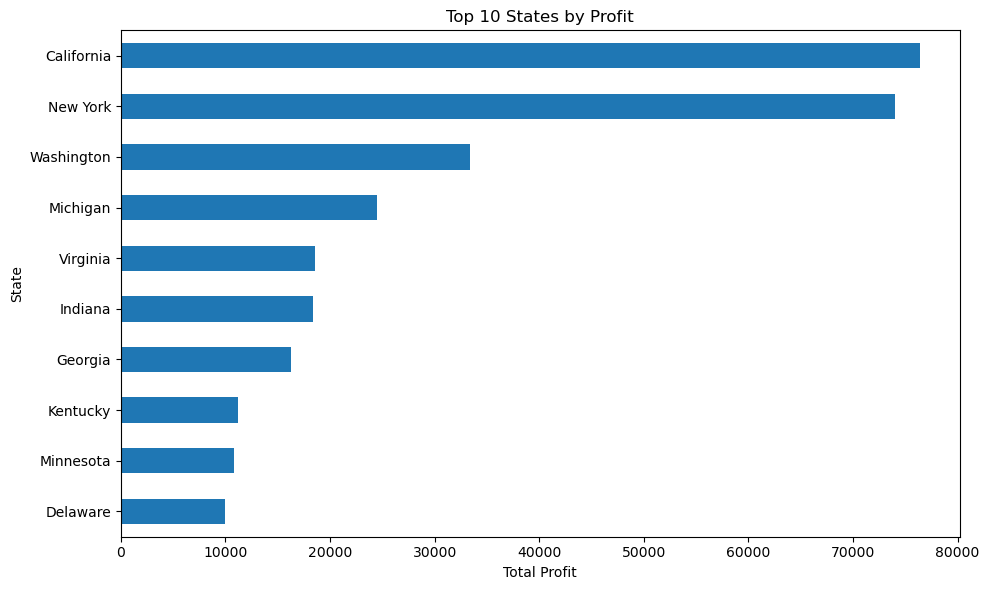

In [156]:
#top 10 states by proft visualization
plt.figure(figsize=(10,6))
top_10_profit_states.sort_values().plot(kind='barh')
plt.title("Top 10 States by Profit")
plt.xlabel("Total Profit")
plt.ylabel("State")
plt.tight_layout()
plt.show()

In [157]:
#Loss Making States
#This is particularly useful because a state can have high sales but still lose money
loss_making_states = profit_by_state[profit_by_state < 0]
loss_making_states

State/Province
Nova Scotia         -52.7420
New Brunswick       -74.1416
Oregon            -1190.4705
Florida           -3399.3017
Arizona           -3427.9246
Tennessee         -5341.6936
Colorado          -6527.8579
North Carolina    -7490.9122
Illinois         -12607.8870
Pennsylvania     -15559.9603
Ohio             -16971.3766
Texas            -25729.3563
Name: Profit, dtype: float64

### Observation
- California recorded the highest sales and profit among all states.
- Several states generated negative overall profit despite contributing to sales.
- Texas recorded the largest loss, followed by Ohio and Pennsylvania.
- The loss-making states indicate potential issues with pricing, discounting, product mix, or operating costs.
### Business Insight
California is the strongest-performing state, generating both the highest sales and profit. However, several states are operating at a loss, with Texas showing the largest negative profit. These states should be investigated further to understand whether high discounts, low-margin products, or other cost factors are affecting profitability.

### Customer & Segment Analysis
Answewrs question 'Which customer segments generate the most sales and profit?'

In [159]:
#sales by segment
sales_by_segment = (
    df.groupby('Segment')['Sales']
      .sum()
      .sort_values(ascending=False)
)
sales_by_segment

Segment
Consumer       1.170660e+06
Corporate      7.158061e+05
Home Office    4.400684e+05
Name: Sales, dtype: float64

In [161]:
#profit by segment
profit_by_segment = (
    df.groupby ('Segment')['Sales']
    .sum()
    .sort_values(ascending=False)
)
profit_by_segment

Segment
Consumer       1.170660e+06
Corporate      7.158061e+05
Home Office    4.400684e+05
Name: Sales, dtype: float64

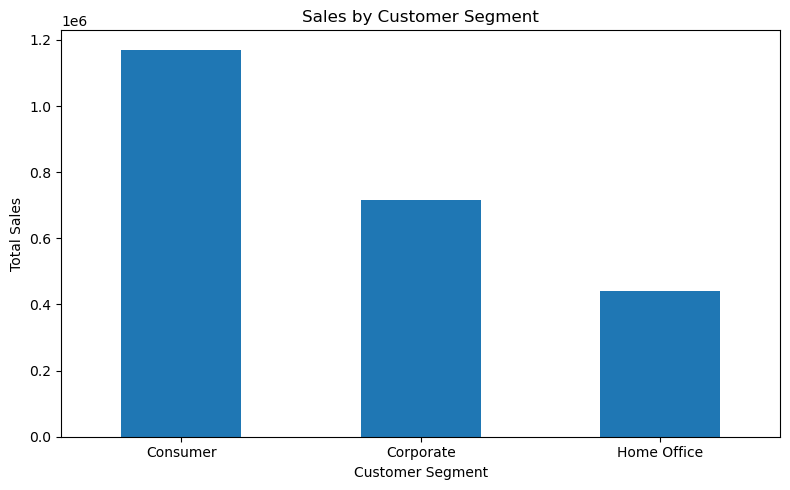

In [162]:
#visualization
plt.figure(figsize=(8,5))
sales_by_segment.plot(kind='bar')
plt.title("Sales by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [163]:
#top 10 customers by sales
top_customers = (
    df.groupby('Customer Name')['Sales']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)
top_customers

Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: Sales, dtype: float64

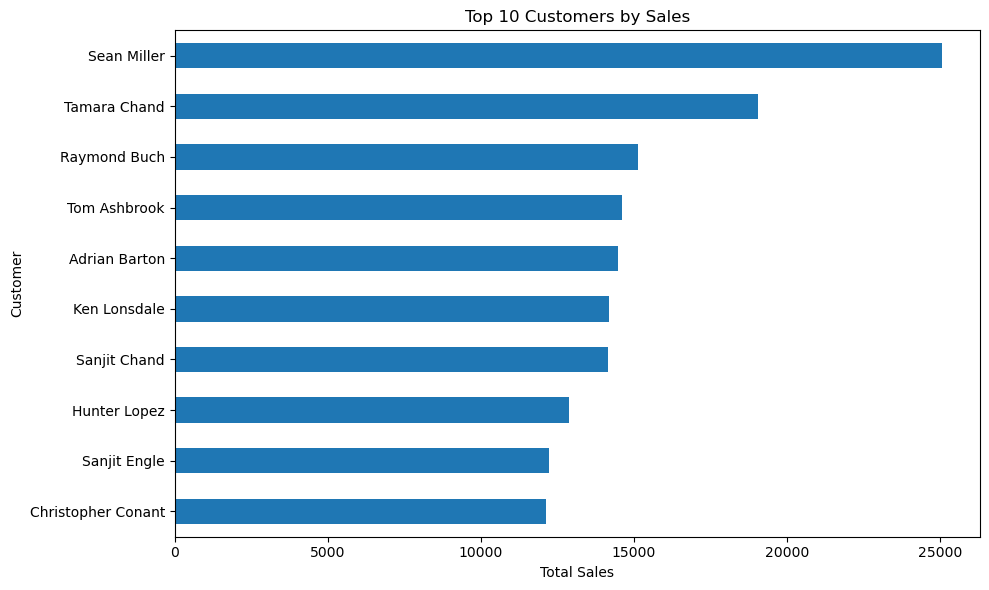

In [164]:
#visualize
plt.figure(figsize=(10,6))
top_customers.sort_values().plot(kind='barh')
plt.title("Top 10 Customers by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Customer")
plt.tight_layout()
plt.show()

### Observation
- The Consumer segment generated the highest sales and profit among the three customer segments.
- Corporate contributed the second-highest overall performance.
- The Home Office segment recorded the lowest sales and profit.
- A small group of customers contributed significantly to overall sales, as seen from the Top 10 customers analysis.
### Business Insight
The Consumer segment is the company's strongest customer segment, making it an important contributor to overall revenue and profitability. The business can focus on retaining high-value Consumer customers while developing targeted strategies to increase sales from the Home Office segment. Identifying and retaining top customers can also help maintain a stable revenue base.

### Time Trend Analysiss
Answers Question 'How do sales and profit change over time?'

In [167]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

In [168]:
#monthly sales
monthly_sales = (
    df.groupby(df['Order Date'].dt.to_period('M'))['Sales']
      .sum()
)
monthly_sales

Order Date
2023-01     14518.0550
2023-02      4519.8920
2023-03     56933.9090
2023-04     28295.3450
2023-05     26319.7670
2023-06     34669.4796
2023-07     33946.3930
2023-08     28918.3385
2023-09     82670.4288
2023-10     32413.3390
2023-11     78826.9567
2023-12     72008.3085
2024-01     18461.9156
2024-02     11951.4110
2024-03     39978.6280
2024-04     34195.2085
2024-05     30246.9465
2024-06     24797.2920
2024-07     28765.3250
2024-08     37057.0042
2024-09     64627.0460
2024-10     31407.1335
2024-11     75972.5635
2024-12     75532.5572
2025-01     18830.3310
2025-02     22978.8150
2025-03     53031.0690
2025-04     38829.1590
2025-05     57042.8380
2025-06     40937.1480
2025-07     40300.4990
2025-08     31716.8143
2025-09     73521.6629
2025-10     59831.0010
2025-11     79411.9658
2025-12     97502.2770
2026-01     44259.2140
2026-02     20301.1334
2026-03     60728.4808
2026-04     36779.0361
2026-05     45155.4822
2026-06     53056.0777
2026-07     45989.4960


In [170]:
#monthly profit
monthly_profit = (
    df.groupby(df['Order Date'].dt.to_period('M'))['Profit']
      .sum()
)
monthly_profit

Order Date
2023-01     2539.3907
2023-02      862.3084
2023-03      693.4499
2023-04     3488.8352
2023-05     3196.3918
2023-06     4999.7594
2023-07     -841.4826
2023-08     5765.2250
2023-09     8593.6302
2023-10     3469.1749
2023-11     9362.9557
2023-12     9554.6571
2024-01    -3189.8030
2024-02     2813.8508
2024-03     9930.6134
2024-04     4187.4962
2024-05     4677.1370
2024-06     3335.5572
2024-07     3288.6483
2024-08     5371.6274
2024-09     8220.0251
2024-10     2817.9660
2024-11    12474.7884
2024-12     8093.0627
2025-01     2916.0233
2025-02     5004.5795
2025-03     3707.8862
2025-04     2991.6609
2025-05     8676.6964
2025-06     4926.3194
2025-07     4559.8827
2025-08     2317.4993
2025-09     9370.1031
2025-10    16256.8422
2025-11     4011.4075
2025-12    17926.3013
2026-01     7231.6391
2026-02     1613.8720
2026-03    15013.0910
2026-04      957.5300
2026-05     6299.8072
2026-06     8246.5707
2026-07     7006.5012
2026-08     9488.0722
2026-09    11050.8024

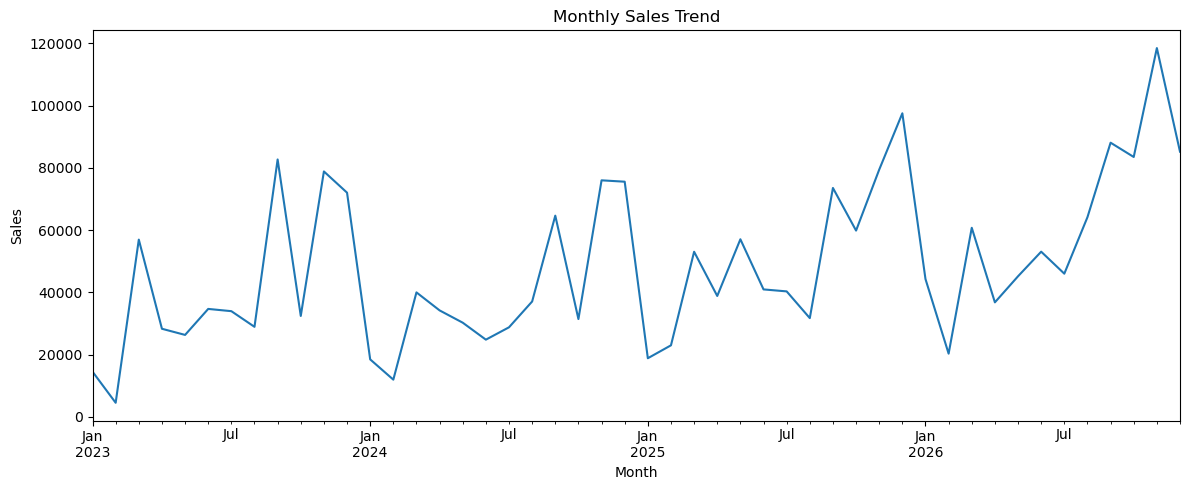

In [171]:
#sales trend
plt.figure(figsize=(12,5))
monthly_sales.plot()
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

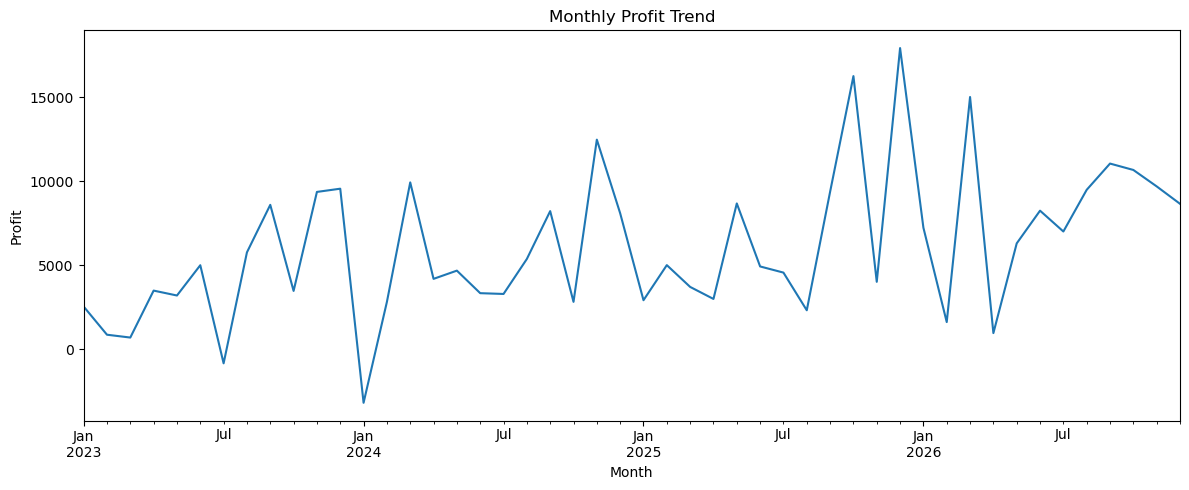

In [172]:
#profit trend
plt.figure(figsize=(12,5))
monthly_profit.plot()
plt.title("Monthly Profit Trend")
plt.xlabel("Month")
plt.ylabel("Profit")
plt.tight_layout()
plt.show()

In [174]:
#yearly sales
yearly_sales = (
    df.groupby(df['Order Date'].dt.year)['Sales']
      .sum()
)
yearly_sales

Order Date
2023    494040.2121
2024    472993.0310
2025    613933.5800
2026    745567.5312
Name: Sales, dtype: float64

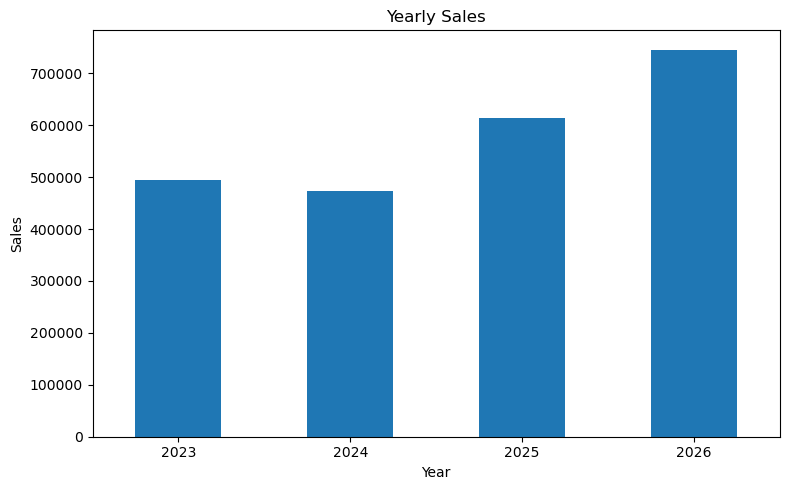

In [175]:
#visualization
plt.figure(figsize=(8,5))
yearly_sales.plot(kind='bar')
plt.title("Yearly Sales")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Observation
- 2026 recorded the highest overall sales among the years analyzed.
- Sales fluctuated over time rather than following a consistent upward trend.
- July showed a noticeable peak in sales.
- Monthly profit also fluctuated, with some months recording negative net profit.
### Business Insight
The business achieved its highest sales in 2026, but the fluctuating sales pattern indicates that revenue is not consistently increasing throughout the year. The noticeable July sales peak could indicate seasonal or demand related factors. Negative profit months should be investigated further to understand the impact of discounts, returns, and product-level profitability.

### Discount & Return Analysis
### Part A: Discount vs Profit
Answers question 'Does giving higher discounts affect profitability?'

In [176]:
#average discount
avg_discount = df['Discount'].mean()
avg_discount

np.float64(0.15538453992544635)

In [178]:
#discount vs profit
discount_profit = (
    df.groupby('Discount')['Profit']
      .mean()
      .sort_index()
)
discount_profit

Discount
0.00     66.338799
0.10     94.791354
0.15     27.288298
0.20     24.576350
0.30    -45.710633
0.32    -88.560656
0.40   -111.528378
0.45   -226.646464
0.50   -310.703456
0.60    -41.371458
0.70    -95.048521
0.80   -101.545745
Name: Profit, dtype: float64

In [180]:
#create discount range
df['Discount Range'] = pd.cut(
    df['Discount'],
    bins=[-0.01, 0.10, 0.20, 0.30, 0.50, 0.80],
    labels=['0–10%', '11–20%', '21–30%', '31–50%', '51–80%']
)

In [181]:
#calculate avg profit
discount_profit = (
    df.groupby('Discount Range', observed=True)['Profit']
      .mean()
)

discount_profit

Discount Range
0–10%      66.882804
11–20%     24.613875
21–30%    -45.710633
31–50%   -155.874762
51–80%    -88.135228
Name: Profit, dtype: float64

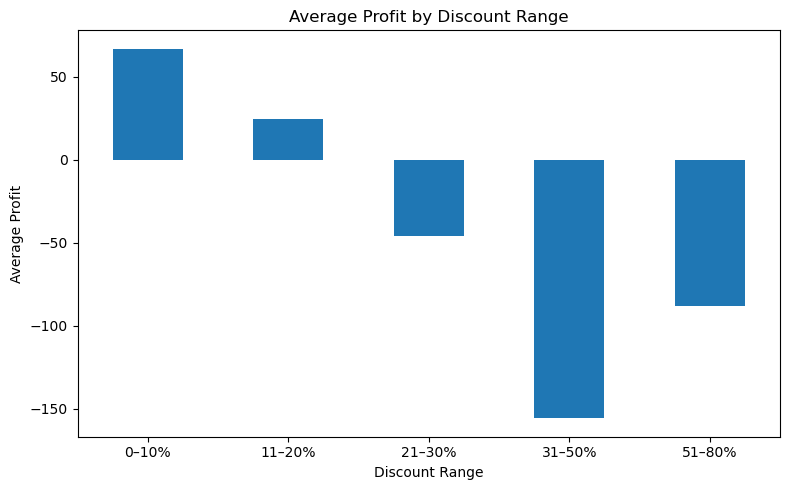

In [183]:
#visualize
plt.figure(figsize=(8,5))
discount_profit.plot(kind='bar')
plt.title('Average Profit by Discount Range')
plt.xlabel('Discount Range')
plt.ylabel('Average Profit')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Part B: Returns Analysis

In [186]:
#load cleaned returns csv
returns_df = pd.read_csv("/Users/aryaapalande/Desktop/Superstore_sales_project/superstore_data_cleaned/returns_cleaned.csv")

In [187]:
returns_df.columns

Index(['Order ID', 'Returned'], dtype='object')

In [188]:
#number of returned orders
returned_orders = returns_df['Order ID'].nunique()
returned_orders

296

In [190]:
#total orders
total_orders = df['Order ID'].nunique()
total_orders

5111

In [191]:
#return rate
return_rate = (returned_orders / total_orders) * 100
return_rate

5.791430248483663

In [192]:
#returned vs non returned orders
df['Returned'] = df['Order ID'].isin(returns_df['Order ID'])

In [193]:
df['Returned'].value_counts()

Returned
False    9394
True      800
Name: count, dtype: int64

### Observation
- Lower discount ranges generated positive average profit.
- Average profit decreased as the discount level increased.
- Higher discount ranges resulted in negative average profit.
- The 31–50% discount range showed a significant decline in profitability.
- Discounts above 50% also resulted in negative average profit.
### Business Insight
The analysis indicates a negative relationship between higher discounts and profitability. While moderate discounts can support sales without significantly reducing profit, excessive discounting can lead to losses. The company should therefore carefully evaluate high-discount orders and use targeted discount strategies to protect profit margins.

### Product analysis

In [198]:
#top 10 products by sales
top_products_sales = (
    df.groupby('Product Name')['Sales']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)
top_products_sales

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64

In [199]:
#top 10 products by profit
top_products_profit = (
    df.groupby('Product Name')['Profit']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)
top_products_profit

Product Name
Canon imageCLASS 2200 Advanced Copier                                          25199.9280
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind     7753.0390
Hewlett Packard LaserJet 3310 Copier                                            6983.8836
Canon PC1060 Personal Laser Copier                                              4570.9347
HP Designjet T520 Inkjet Large Format Printer - 24" Color                       4094.9766
Ativa V4110MDD Micro-Cut Shredder                                               3772.9461
3D Systems Cube Printer, 2nd Generation, Magenta                                3717.9714
Plantronics Savi W720 Multi-Device Wireless Headset System                      3696.2820
Ibico EPK-21 Electric Binding System                                            3345.2823
Zebra ZM400 Thermal Label Printer                                               3343.5360
Name: Profit, dtype: float64

In [200]:
#bottom 10 products by profit
bottom_products_profit = (
    df.groupby('Product Name')['Profit']
      .sum()
      .sort_values()
      .head(10)
)
bottom_products_profit

Product Name
Cubify CubeX 3D Printer Double Head Print                           -8879.9704
Lexmark MX611dhe Monochrome Laser Printer                           -4589.9730
Cubify CubeX 3D Printer Triple Head Print                           -3839.9904
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases            -2876.1156
Bush Advantage Collection Racetrack Conference Table                -1934.3976
GBC DocuBind P400 Electric Binding System                           -1878.1662
Cisco TelePresence System EX90 Videoconferencing Unit               -1811.0784
Martin Yale Chadless Opener Electric Letter Opener                  -1299.1836
Balt Solid Wood Round Tables                                        -1201.0581
BoxOffice By Design Rectangular and Half-Moon Meeting Room Tables   -1148.4375
Name: Profit, dtype: float64

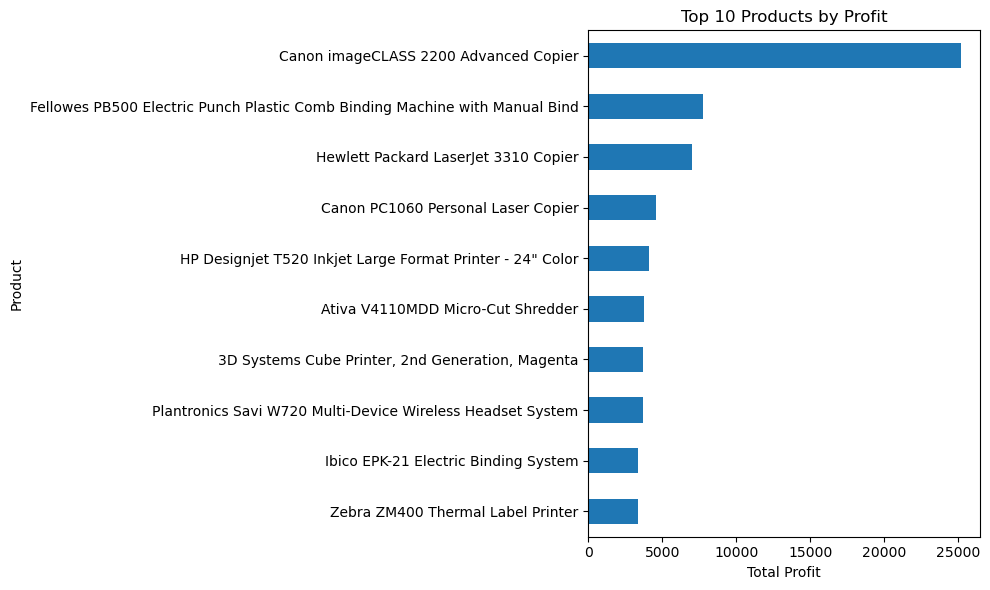

In [201]:
#visualize top 10 products by profit
plt.figure(figsize=(10,6))
top_products_profit.sort_values().plot(kind='barh')
plt.title('Top 10 Products by Profit')
plt.xlabel('Total Profit')
plt.ylabel('Product')
plt.tight_layout()
plt.show()

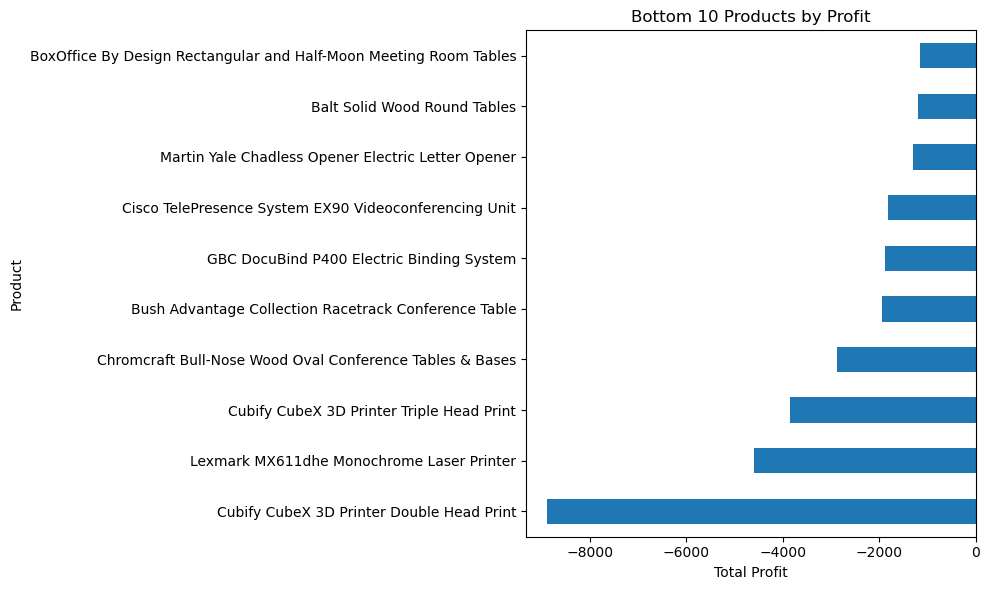

In [202]:
#visualize bottom 10 products by profit
plt.figure(figsize=(10,6))
bottom_products_profit.sort_values().plot(kind='barh')
plt.title('Bottom 10 Products by Profit')
plt.xlabel('Total Profit')
plt.ylabel('Product')
plt.tight_layout()
plt.show()

### Observation
- Canon imageCLASS 2200 Advanced Copier is the top-performing product in both sales and profit.
- Fellowes PB500 Electric Punch Plastic Comb Binding Machine is the second-highest product by sales and profit.
- Several high-selling products also generate strong profits, but high sales do not always guarantee profitability.
- Cubify CubeX 3D Printer Double Head Print recorded the largest loss, followed by Lexmark MX611dhe Monochrome Laser Printer.
- Some products, such as the GBC DocuBind P400 and Cisco TelePresence System EX90, appear among both high-profit/high-sales and loss-making results, indicating that product-level performance may vary across orders.

### Business Insight

The Canon imageCLASS 2200 Advanced Copier is a key contributor to both revenue and profitability and should be prioritized for inventory and sales strategies. However, several products generate significant losses despite contributing to sales. The company should investigate pricing, discount levels, and return patterns for these products and consider optimizing or reducing sales of consistently loss-making products.

## Final Business Insights

1. California is the strongest-performing state in terms of both sales and profit.

2. The Consumer segment contributes the highest overall sales and profit.

3. Sales fluctuate over time rather than following a consistent upward trend, with July showing a noticeable sales peak.

4. Higher discounts are associated with lower profitability, with higher discount ranges generally producing negative average profit.

5. Several states generate negative overall profit, with Texas recording the largest loss.

6. The Canon imageCLASS 2200 Advanced Copier is the strongest product in terms of both sales and profit.

7. Several products generate significant losses and should be investigated based on pricing, discounts, and returns.

8. The presence of negative-profit months and products indicates that increasing sales alone does not necessarily guarantee higher profitability.